# Sponsored Advertisement Conversion

In [117]:
import numpy as  np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import math

import warnings
warnings.filterwarnings('ignore')

## 1. Problem Statement

The objective of this project is to develop a Machine Learning-based binary classification model that predicts whether a user interaction with a sponsored advertisement on an e-commerce platform will result in a product purchase (conversion).
Every row in the dataset represents a sponsored advertisement interaction containing information about the user, product, campaign, advertisement, engagement behavior, historical activity, and browsing context. 

The target variable is conversion, where:
- 1 = Purchase/Conversion
- 0 = No Purchase

## 2. Data Gathering

In [118]:
df_ecommerce = pd.read_excel('ad_CVR.xlsx')
df_ecommerce.head()

,user_id,user_age,gender,income_level,user_segment,location_type,previous_purchases,days_since_last_purchase,platform,campaign_id,...,click_through_rate,device_type,traffic_source,day_of_week,hour_of_day,engagement_score,customer_lifetime_value,previous_conversion_rate,discount_percentage,conversion
0,120063,41,Male,Low,New User,Suburban,1,172,Target,1063,...,13.892,Mobile,Direct,Sunday,23.0,37.43,1421.45,34.83,3.73,0
1,120646,43,Male,High,Occasional Buyer,Urban,3,118,Best Buy,1146,...,15.893,Tablet,Social Media,Monday,15.0,58.39,1154.38,22.64,46.48,1
2,116877,53,Female,Middle,Occasional Buyer,Urban,3,167,Target,1048,...,14.158,Desktop,Direct,Tuesday,10.0,14.41,1376.90,0.00,17.78,0
3,101238,20,Female,Middle,Loyal Customer,Urban,1,34,Best Buy,1020,...,17.457,Mobile,Social Media,Saturday,19.0,42.70,1308.96,17.19,26.81,1
4,118683,42,Female,Low,New User,Rural,0,128,Amazon,1045,...,25.755,Mobile,Paid Search,Thursday,3.0,15.72,1342.25,18.14,31.73,0


## 3. EDA

### Dataset structure analysis

In [119]:
df_ecommerce.shape

(30080, 34)

In [120]:
df_ecommerce.info()

<class 'pandas.DataFrame'>
RangeIndex: 30080 entries, 0 to 30079
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   30080 non-null  int64  
 1   user_age                  30080 non-null  int64  
 2   gender                    30080 non-null  str    
 3   income_level              30080 non-null  str    
 4   user_segment              30080 non-null  str    
 5   location_type             30080 non-null  str    
 6   previous_purchases        30080 non-null  int64  
 7   days_since_last_purchase  30080 non-null  int64  
 8   platform                  30080 non-null  str    
 9   campaign_id               30080 non-null  int64  
 10  campaign_type             30080 non-null  str    
 11  ad_id                     30080 non-null  int64  
 12  ad_position               30080 non-null  str    
 13  ad_format                 30080 non-null  str    
 14  bid_amount       

- Dataset contains 30,080 records and 34 columns.
- Target variable conversion has no missing values and is stored as an integer.
- Dataset contains 12 categorical and 21 numerical features.
- user_id, campaign_id, and ad_id are identifier columns to be evaluated during preprocessing.
- Some missing values are present in numerical features and will be handled during preprocessing.
- Features cover user behaviour, campaign details, ad characteristics, engagement, and browsing context, making them relevant for conversion prediction.

### Missing Value analysis

In [121]:
df_ecommerce.isnull().sum()

user_id                      0
user_age                     0
gender                       0
income_level                 0
user_segment                 0
location_type                0
previous_purchases           0
days_since_last_purchase     0
platform                     0
campaign_id                  0
campaign_type                0
ad_id                        0
ad_position                  0
ad_format                    0
bid_amount                   0
ad_cost                     14
target_audience              0
campaign_duration_days      11
impressions                  0
clicks                       0
time_on_ad_seconds          13
time_on_page_seconds         9
pages_viewed                 6
previous_ad_clicks           0
click_through_rate           0
device_type                  0
traffic_source               0
day_of_week                  0
hour_of_day                  7
engagement_score             0
customer_lifetime_value     12
previous_conversion_rate     0
discount

- A very small number of missing values are present in a few numerical features, with no significant missing-value issue. These will be handled during preprocessing.

### Statistical analysis

In [122]:
df_ecommerce.describe()

,user_id,user_age,previous_purchases,days_since_last_purchase,campaign_id,ad_id,bid_amount,ad_cost,campaign_duration_days,impressions,...,time_on_page_seconds,pages_viewed,previous_ad_clicks,click_through_rate,hour_of_day,engagement_score,customer_lifetime_value,previous_conversion_rate,discount_percentage,conversion
count,30080.000000,30080.000000,30080.000000,30080.000000,30080.000000,30080.000000,30080.000000,30066.000000,30069.000000,30080.000000,...,30071.000000,30074.000000,30080.000000,30080.000000,30073.000000,30080.000000,30068.000000,30080.000000,30072.000000,30080.000000
mean,114997.362134,38.958976,2.210871,92.531915,1100.879521,504983.122872,8.840918,9.332505,33.463467,12765.670545,...,48.386747,7.965086,2.493551,15.102699,11.475875,32.957950,1241.804057,17.455684,24.895135,0.241689
std,8661.460034,12.414462,1.491149,51.244463,57.774532,2903.831530,4.187858,5.521578,15.578833,7070.217980,...,32.356823,4.330221,1.576203,8.561397,6.918729,11.044423,375.826938,10.056069,14.437367,0.428114
min,100001.000000,18.000000,0.000000,1.000000,1001.000000,500001.000000,1.500000,1.500000,7.000000,500.000000,...,2.000000,1.000000,0.000000,0.159000,0.000000,0.000000,415.070000,0.000000,0.000000,0.000000
25%,107493.750000,28.000000,1.000000,49.000000,1051.000000,502446.750000,5.880000,5.490000,20.000000,6668.000000,...,24.870000,4.000000,1.000000,8.549000,5.000000,25.270000,974.187500,10.190000,12.350000,0.000000
50%,114993.500000,39.000000,2.000000,93.000000,1101.000000,504975.500000,7.980000,8.010000,33.000000,12812.000000,...,40.650000,8.000000,2.000000,13.767000,11.000000,32.800000,1183.940000,17.110000,24.850000,0.000000
75%,122500.250000,50.000000,3.000000,136.000000,1151.000000,507496.000000,10.830000,11.657500,47.000000,18851.750000,...,64.025000,12.000000,3.000000,20.192000,18.000000,40.350000,1442.840000,24.140000,37.380000,0.000000
max,130000.000000,60.000000,11.000000,180.000000,1200.000000,509999.000000,35.000000,40.000000,60.000000,24998.000000,...,263.210000,15.000000,10.000000,63.872000,23.000000,78.390000,4011.120000,66.870000,50.000000,1.000000


- The numerical features have different ranges and scales.
- user_age ranges from 18 to 60 years.
- previous_purchases ranges from 0 to 11, representing both new and repeat customers.
- days_since_last_purchase ranges from 1 to 180 days, showing variation in customer recency.
- bid_amount and ad_cost show considerable variation across advertisements.
- Engagement features such as impressions, clicks, time spent, pages viewed and engagement score show variation in user interaction.
- Customer-related features such as customer lifetime value and previous conversion rate also show noticeable variation.

### Duplicate analysis

In [123]:
df_ecommerce.duplicated().sum()

np.int64(80)

- 80 duplicate records are present in the dataset.
- These duplicate records  will be removed during the data preprocessing stage.

### Target analysis

In [124]:
df_ecommerce['conversion'].value_counts(normalize="true")

conversion
0    0.758311
1    0.241689
Name: proportion, dtype: float64

- 75.83% of records belong to Non-Conversion (0).
- 24.17% of records belong to Conversion (1).
- The target variable is moderately imbalanced, with Non-Conversion as the majority class.
Therefore, Accuracy alone should not be used for model evaluation; Precision, Recall, F1-Score and ROC-AUC should also be considered.

### Univariate analysis

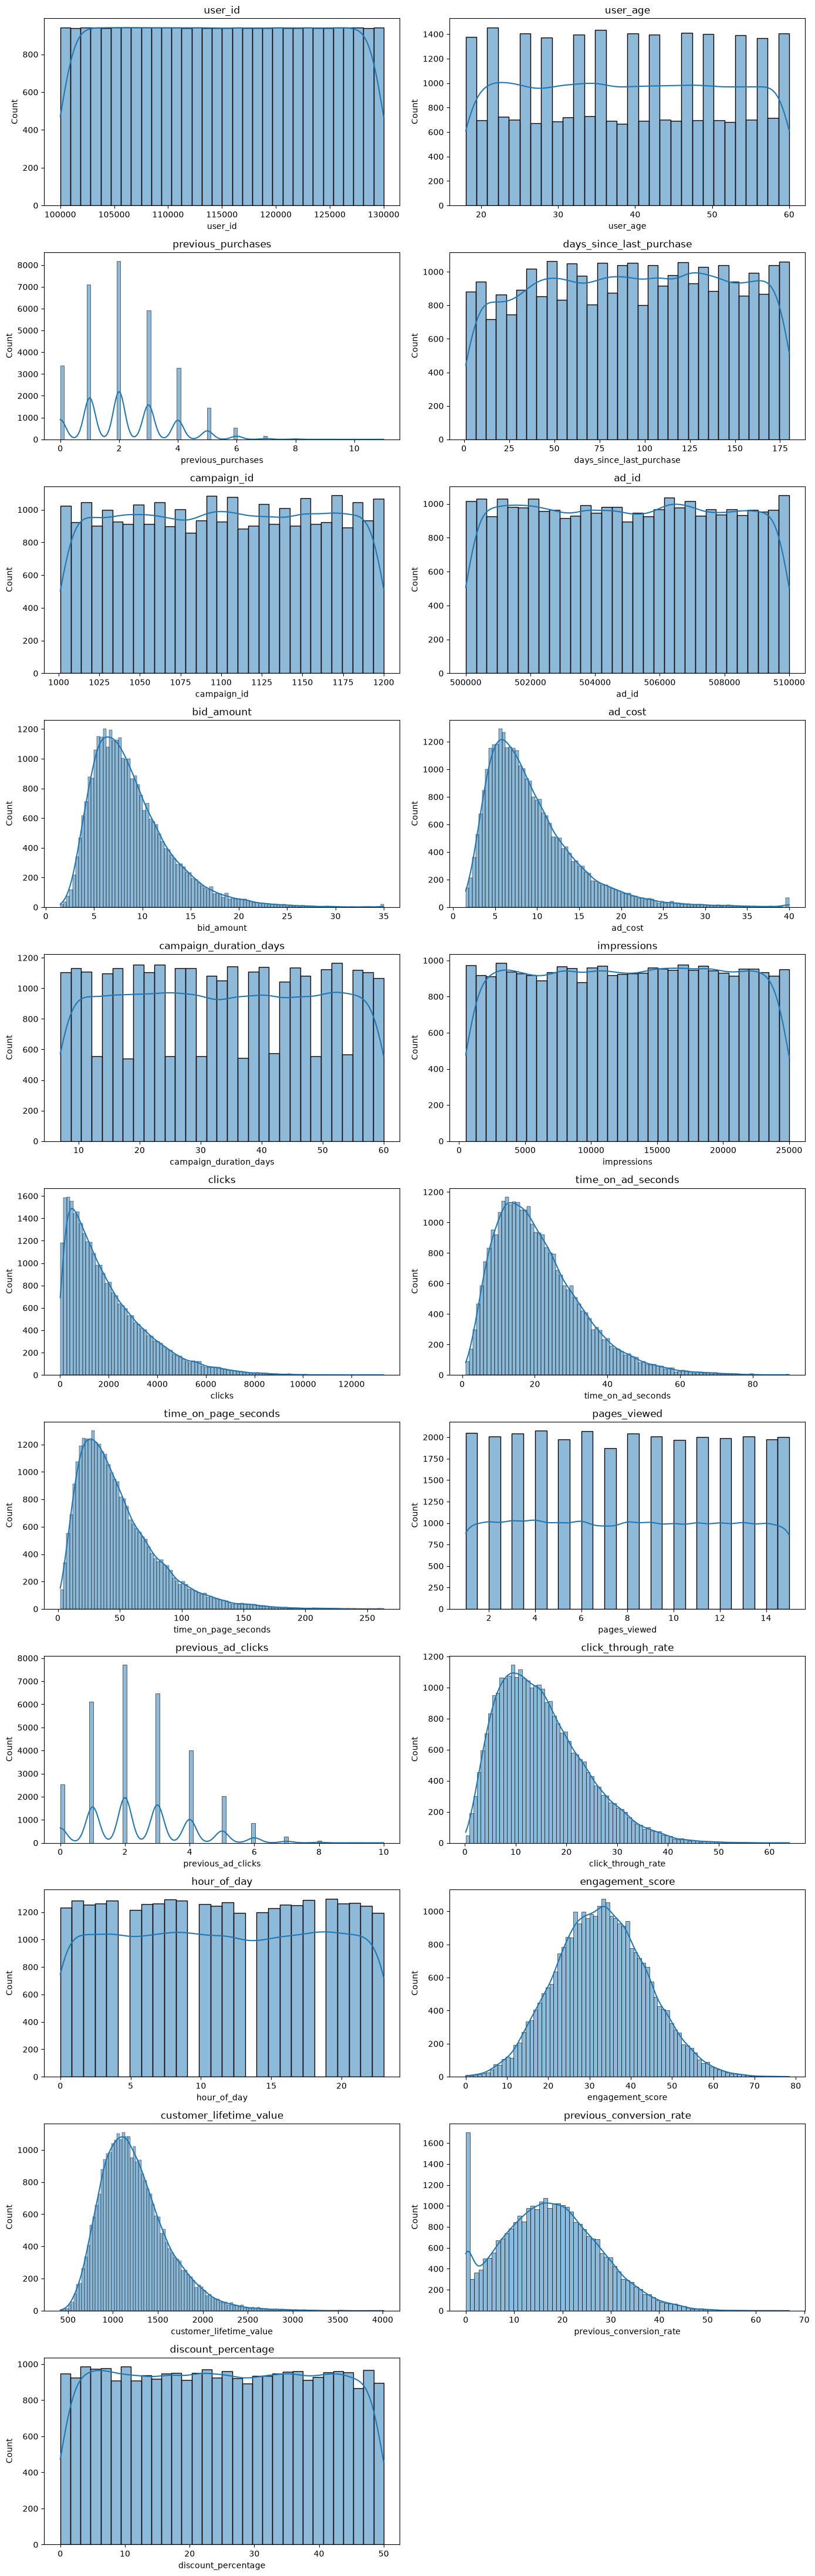

In [125]:
def plot_histograms(df, columns):
    rows = math.ceil(len(columns) / 2)

    fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        sns.histplot(df[col], kde=True, ax=axes[i])
        axes[i].set_title(col)

    # Remove extra empty plots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

numerical_cols = df_ecommerce.select_dtypes(include=["number"]).columns
numerical_cols = numerical_cols.drop("conversion")

plot_histograms(df_ecommerce, numerical_cols)

- user_age, days_since_last_purchase, campaign_duration_days, impressions, pages_viewed, hour_of_day and discount_percentage show fairly spread distributions across their respective ranges.
- bid_amount, ad_cost, clicks, time_on_ad_seconds, time_on_page_seconds, click_through_rate and customer_lifetime_value show right-skewed distributions.
- engagement_score shows an approximately bell-shaped distribution, with most values concentrated around the center.
- previous_purchases and previous_ad_clicks are discrete features, with values concentrated at specific levels.
- previous_conversion_rate shows a higher concentration at zero with a right-skewed distribution.
- user_id, campaign_id and ad_id show near-uniform distributions and behave like identifier columns, so they can be evaluated for removal during preprocessing.

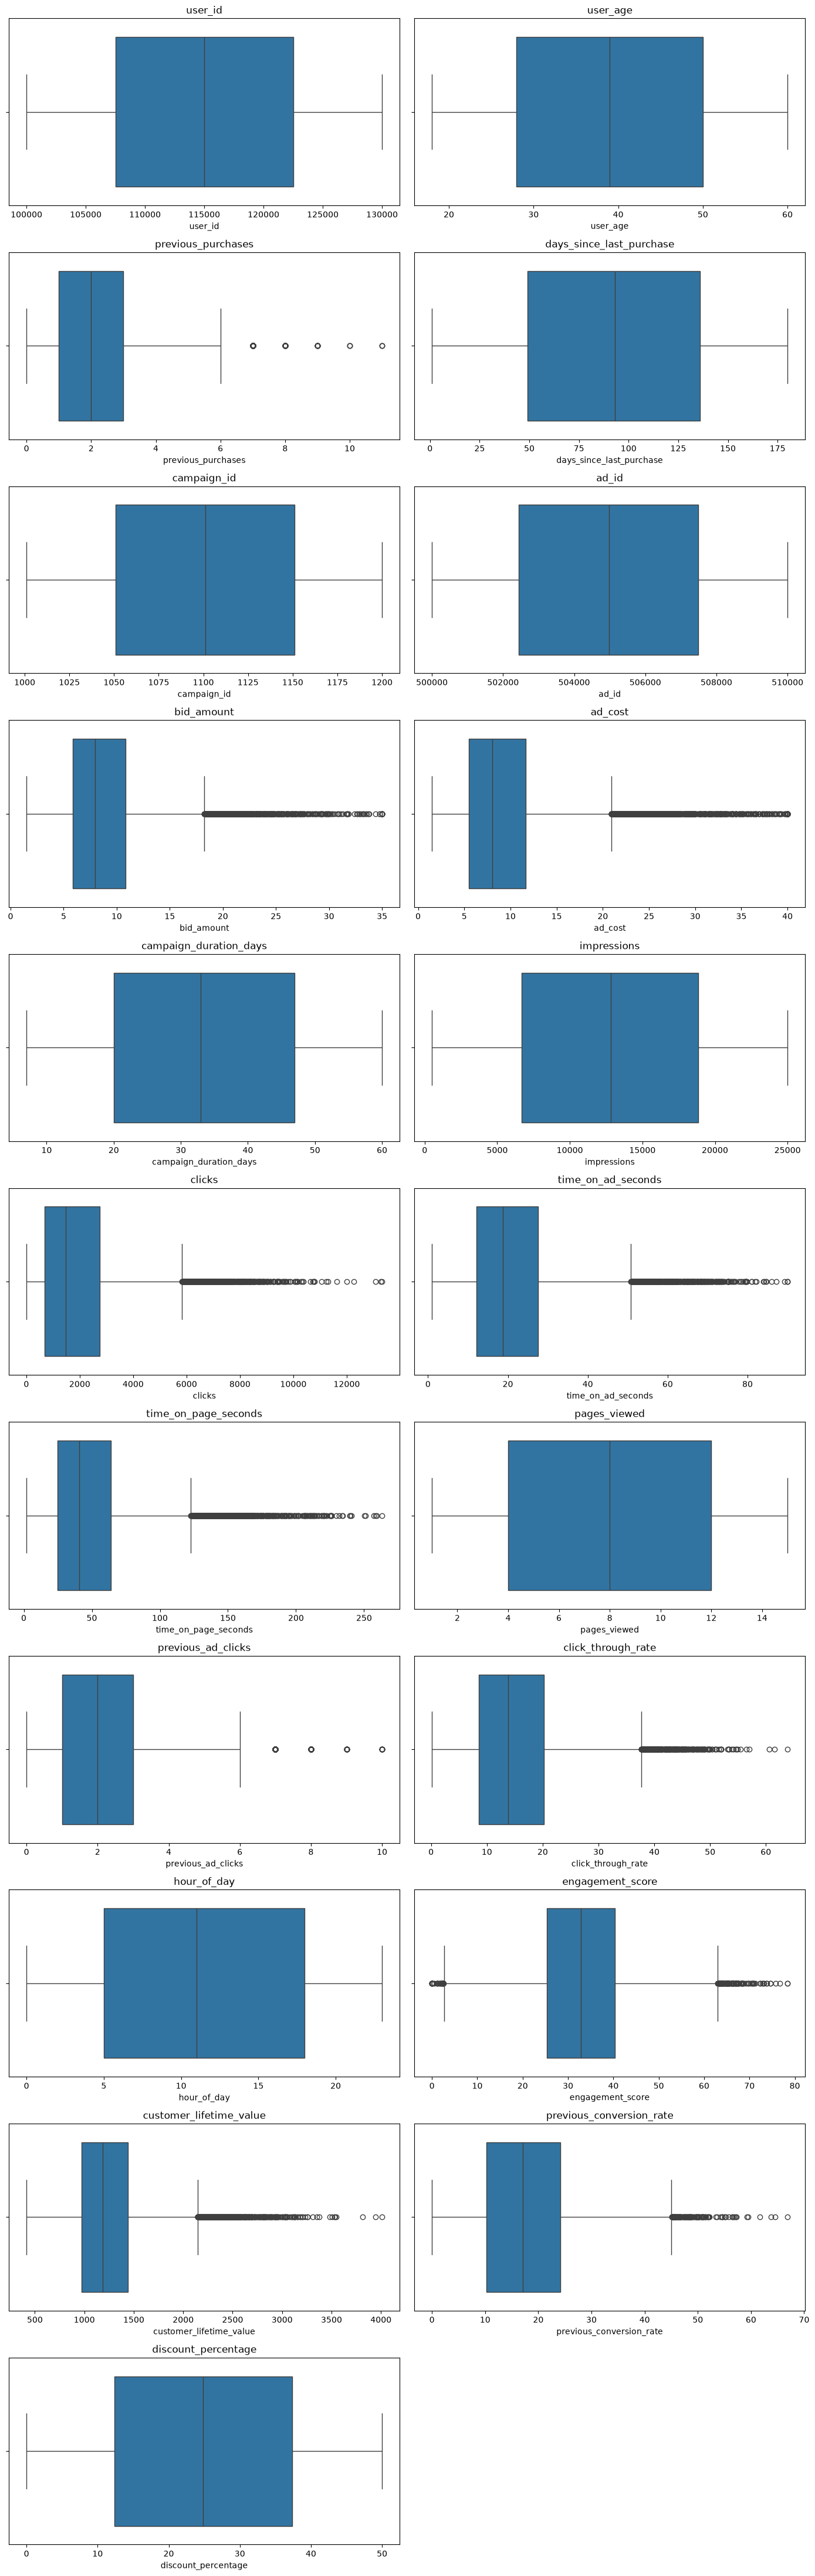

In [126]:
def plot_boxplots(df, columns):
    rows = math.ceil(len(columns) / 2)

    fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        sns.boxplot(x=df[col], ax=axes[i])
        axes[i].set_title(col)

    # Remove extra empty plots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


plot_boxplots(df_ecommerce, numerical_cols)

- bid_amount, ad_cost, clicks, time_on_ad_seconds, time_on_page_seconds, click_through_rate and customer_lifetime_value show a noticeable number of upper-end outliers.
- engagement_score and previous_conversion_rate also show some upper-end outliers.
- previous_purchases and previous_ad_clicks contain a small number of high-value outliers.
- user_age, days_since_last_purchase, campaign_duration_days, impressions, pages_viewed, hour_of_day and discount_percentage show no major outlier concern.
- user_id, campaign_id and ad_id do not show meaningful outliers because they are identifier columns and will be evaluated for removal.

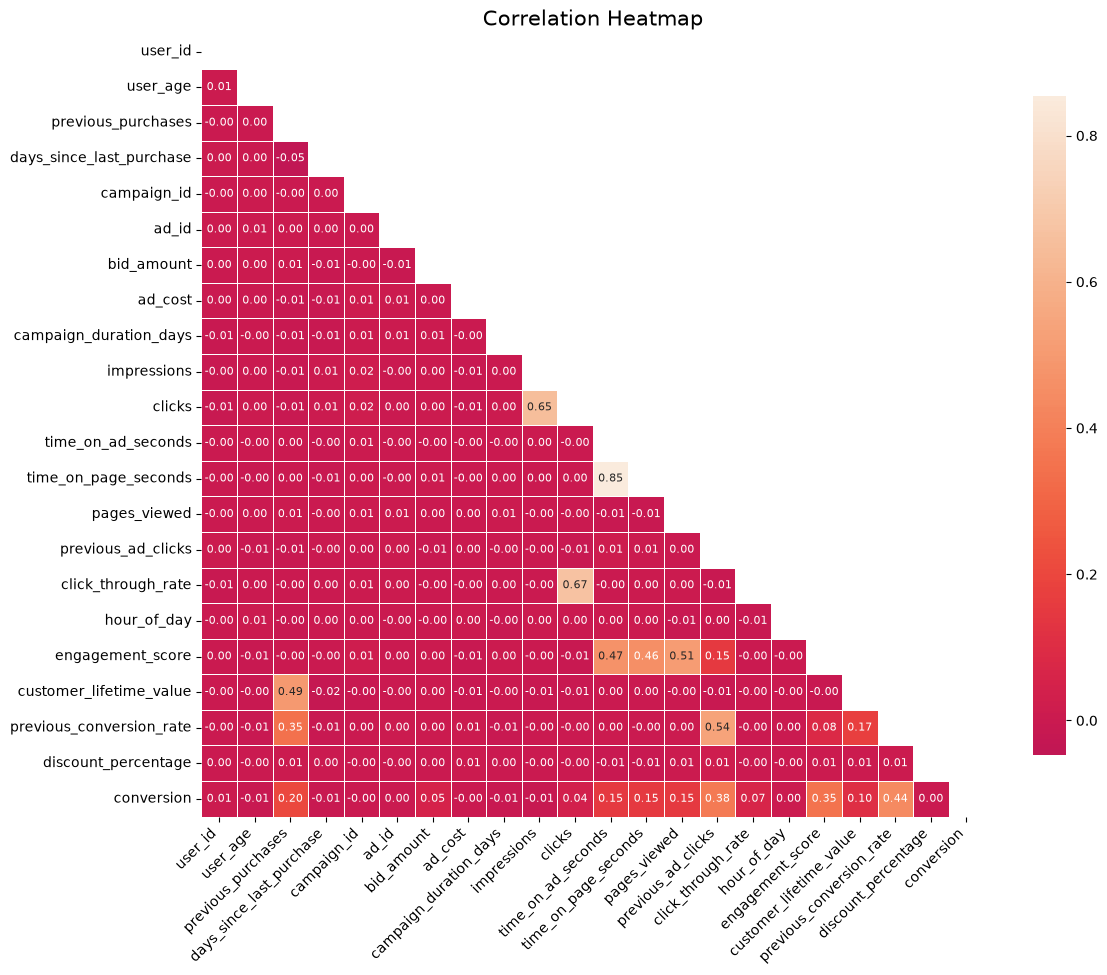

In [127]:
# Correlation Matrix

corr = df_ecommerce.select_dtypes(include=["number"]).corr()

# Hide upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    mask=mask,
    cmap="rocket",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8}
)

plt.title("Correlation Heatmap", fontsize=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [128]:
# Keep only strong correlations (>=0.30)

corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)

corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

important_corr = corr_pairs[
    corr_pairs["Correlation"].abs() >= 0.30
].sort_values(by="Correlation", ascending=False)

important_corr

,Feature 1,Feature 2,Correlation
254,time_on_ad_seconds,time_on_page_seconds,0.854261
235,clicks,click_through_rate,0.668966
208,impressions,clicks,0.647163
327,previous_ad_clicks,previous_conversion_rate,0.535512
303,pages_viewed,engagement_score,0.512381
62,previous_purchases,customer_lifetime_value,0.492223
259,time_on_ad_seconds,engagement_score,0.470971
281,time_on_page_seconds,engagement_score,0.458982
439,previous_conversion_rate,conversion,0.438313
329,previous_ad_clicks,conversion,0.376550


- Most numerical features show weak correlation with each other.
- Stronger relationships are observed between time_on_ad_seconds and time_on_page_seconds (0.85), clicks and impressions (0.65), and clicks and click_through_rate (0.67).
- previous_purchases has a moderate positive relationship with customer_lifetime_value (0.49).
- previous_ad_clicks has a moderate positive relationship with previous_conversion_rate (0.54).
- The target conversion shows its higher numerical correlations with previous_conversion_rate (0.44), previous_ad_clicks (0.38), and engagement_score (0.35).
- No feature will be removed based only on correlation; feature usefulness will be evaluated during model building.

### Bivariate analysis

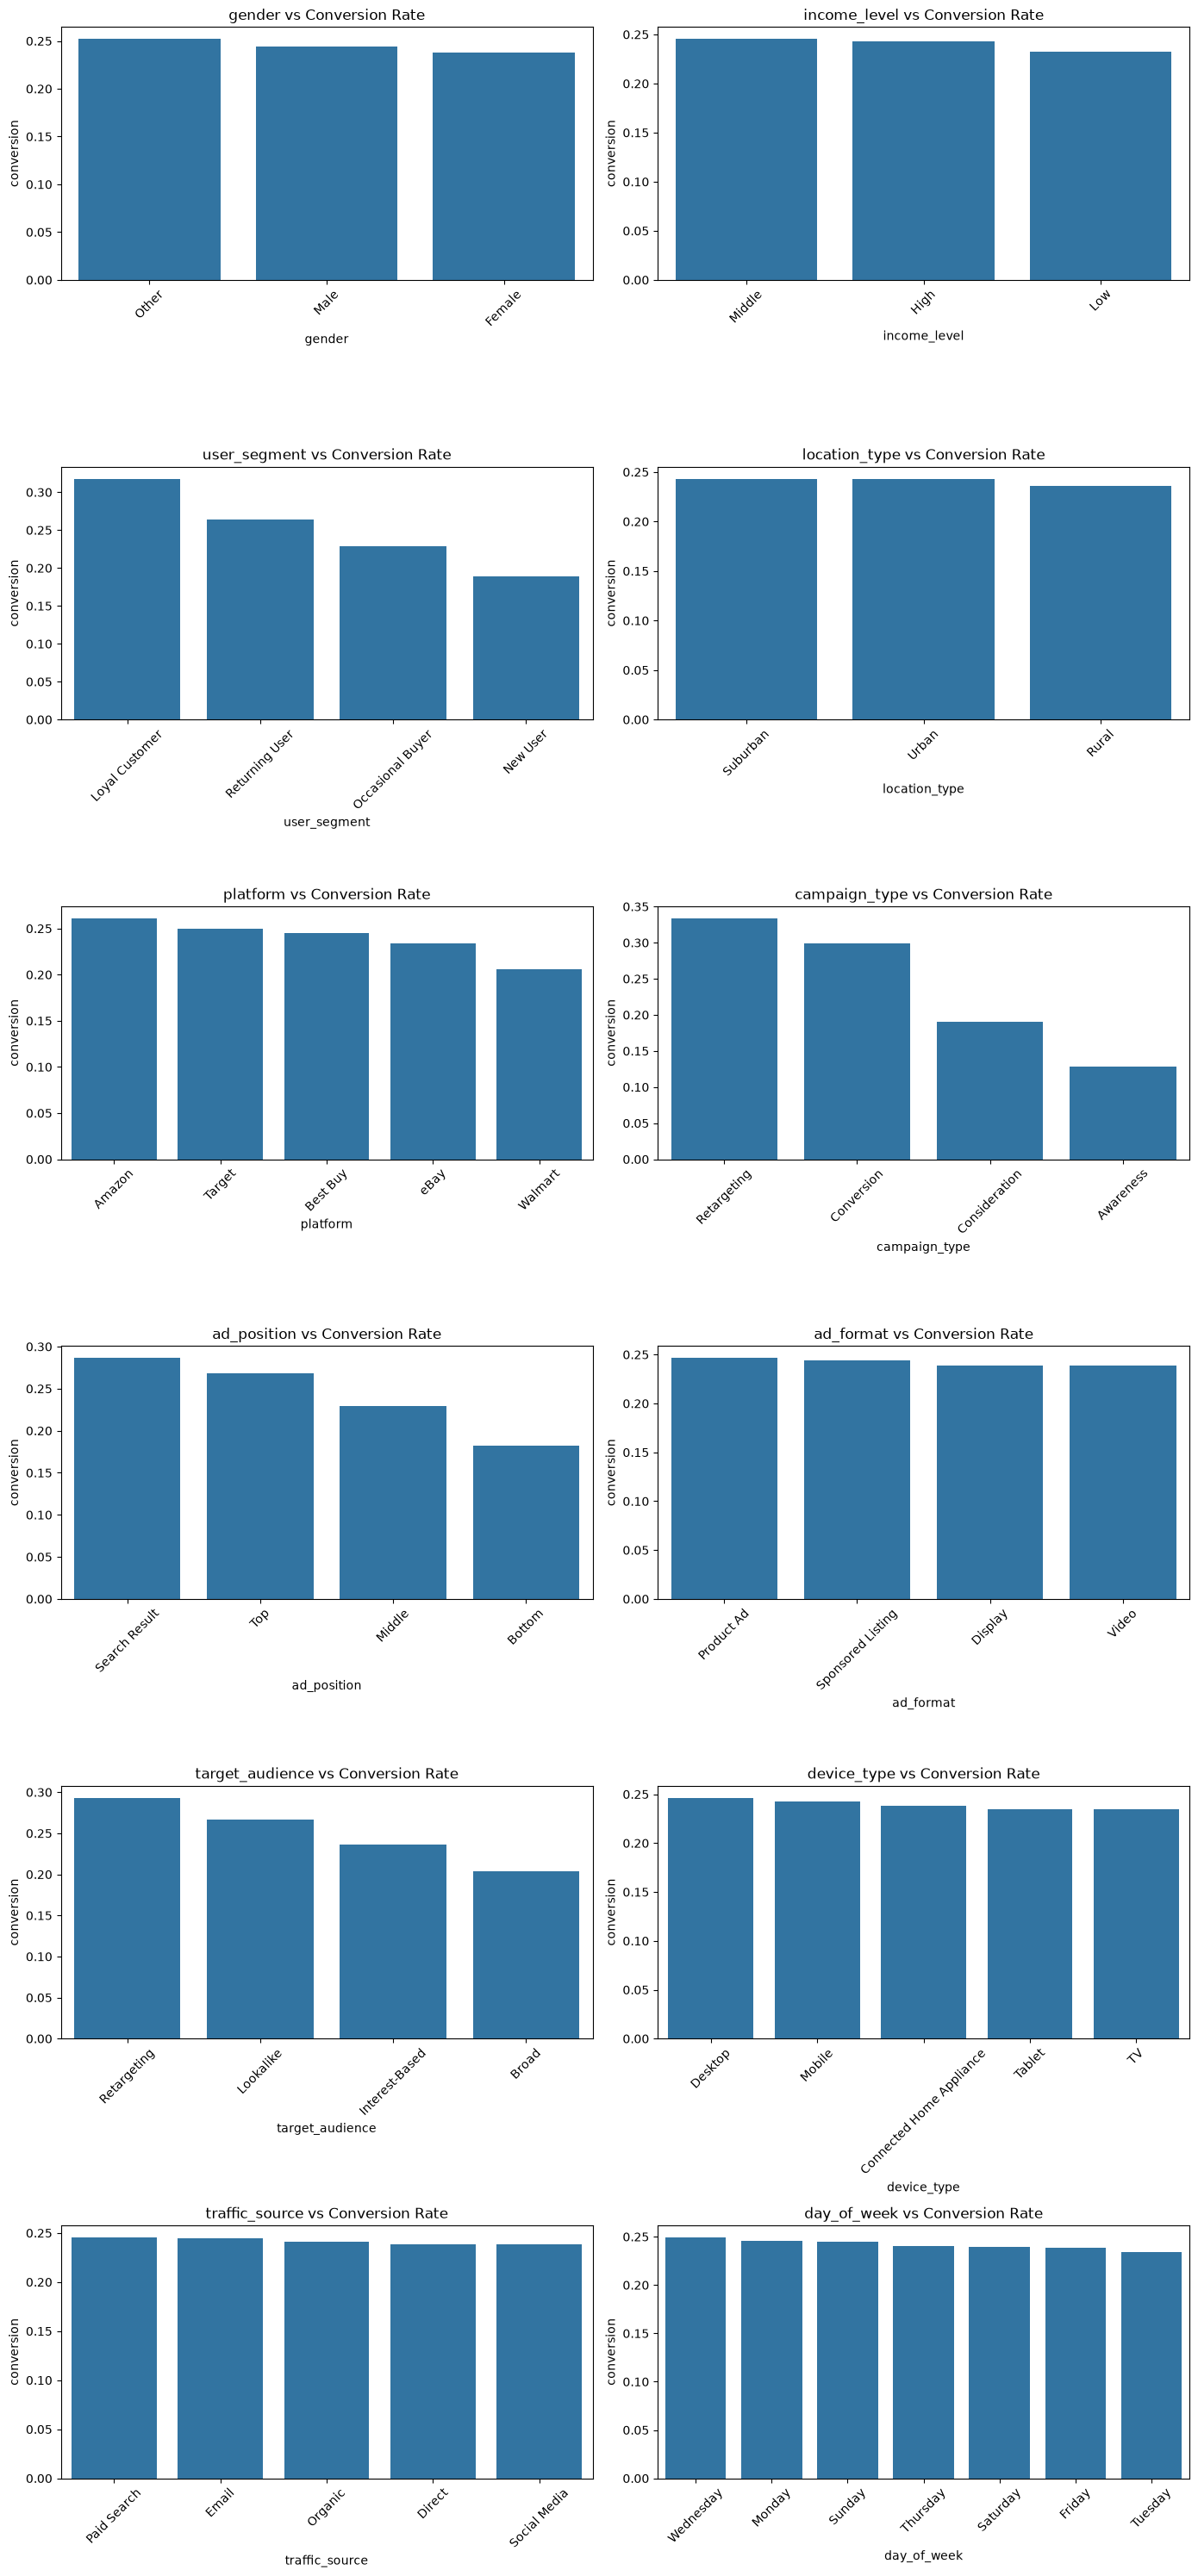

In [129]:
# Categorical Features vs Conversion

def plot_categorical_conversion(df, columns, target="conversion"):
    
    rows = math.ceil(len(columns) / 2)

    fig, axes = plt.subplots(rows, 2, figsize=(14, 5 * rows))
    axes = axes.flatten()

    for i, col in enumerate(columns):

        conversion_rate = (
            df.groupby(col)[target]
            .mean()
            .sort_values(ascending=False)
            .reset_index()
        )

        sns.barplot(
            data=conversion_rate,
            x=col,
            y=target,
            ax=axes[i]
        )

        axes[i].set_title(f"{col} vs Conversion Rate")
        axes[i].tick_params(axis="x", rotation=45)

    # Remove empty plots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


categorical_cols = ["gender","income_level","user_segment","location_type","platform","campaign_type","ad_position",
                    "ad_format","target_audience","device_type","traffic_source","day_of_week"]

plot_categorical_conversion(df_ecommerce, categorical_cols)

- campaign_type, ad_position, target_audience and user_segment show noticeable differences in conversion rates across categories.
- Retargeting has the highest conversion rate among target_audience categories, while Broad has the lowest.
- Retargeting campaign type has the highest conversion rate, while Awareness has the lowest.
- Search Result ad position has a higher conversion rate than Middle and Bottom positions.
- Loyal Customer has the highest conversion rate among user segments, while New User has the lowest.
- Platform, device type, traffic source, day of week, gender, income level, ad format and location type show relatively small differences in conversion rates.

## EDA Summary

- The dataset contains 30,080 records and 34 columns, with a mix of numerical and categorical features.
- A small number of missing values are present in a few numerical features and will be handled during preprocessing.
- The target variable is moderately imbalanced, with approximately 75.8% non-conversion and 24.2% conversion records.
- Numerical features show different distribution patterns, with right-skewness and potential outliers in several advertising, engagement and customer-value features.
- Correlation analysis revealed some strong relationships among numerical features, while the target also shows relationships with features such as previous_conversion_rate, previous_ad_clicks and engagement_score.
- Categorical analysis shows noticeable differences in conversion rates for features such as campaign_type, ad_position, target_audience and user_segment.
- Identifier columns such as user_id, campaign_id and ad_id will be evaluated for removal during preprocessing, while categorical features will be appropriately encoded.

## 4. Data Preprocessing

### 4.1 Data cleaning

In [130]:
# Removing all duplicate rows
df_ecommerce = df_ecommerce.drop_duplicates()

In [131]:
df_ecommerce.duplicated().sum() # verifying that now we dont have any duplicate values 

np.int64(0)

In [132]:
df_ecommerce.shape

(30000, 34)

### Train-Test Split

In [133]:
# Separate features and target
x = df_ecommerce.drop("conversion", axis=1)
y = df_ecommerce["conversion"]

In [134]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

print("Train:", x_train.shape)
print("Test:", x_test.shape)

Train: (24000, 33)
Test: (6000, 33)


- The target variable conversion was separated from the input features before splitting.
- The dataset was split into 80% training (24,080 rows) and 20% testing (6,000 rows).
- Stratified sampling was used to maintain the original conversion/non-conversion ratio in both training and testing datasets.
- The test set will be kept unseen during preprocessing and model training for unbiased final evaluation.

### 4.2 Missing Value Treatment

In [135]:
missing_cols = [
    "ad_cost",
    "campaign_duration_days",
    "time_on_ad_seconds",
    "time_on_page_seconds",
    "pages_viewed",
    "hour_of_day",
    "customer_lifetime_value",
    "discount_percentage"
]

for col in missing_cols:
    median_value = x_train[col].median()
    
    x_train[col] = x_train[col].fillna(median_value)
    x_test[col] = x_test[col].fillna(median_value)

In [136]:
x_train.isnull().sum().sum(), x_test.isnull().sum().sum()

(np.int64(0), np.int64(0))

- Missing values in numerical features were imputed using the median.
- The median was calculated from x_train and the same values were applied to x_test to prevent data leakage.
- After imputation, both x_train and x_test contain 0 missing values.

### 4.3 Outlier Handeling

In [137]:
cap_cols = [
    "bid_amount",
    "ad_cost",
    "clicks",
    "time_on_ad_seconds",
    "time_on_page_seconds",
    "click_through_rate",
    "customer_lifetime_value"
]
def cap_outliers(x_train, x_test, columns):
    for col in columns:
        Q1 = x_train[col].quantile(0.25)
        Q3 = x_train[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        x_train[col] = x_train[col].clip(lower=lower, upper=upper)
        x_test[col] = x_test[col].clip(lower=lower, upper=upper)

cap_outliers(x_train, x_test, cap_cols)

- IQR-based capping was applied selectively to features with significant upper-end outliers identified during EDA.
- The treatment was applied to bid_amount, ad_cost, clicks, time_on_ad_seconds, time_on_page_seconds, click_through_rate and customer_lifetime_value.
- Upper extreme values were capped at the IQR-based upper limits, while all records were retained.
- The treatment reduced the influence of extreme values while preserving the overall data.

#### 4.4 Drop Identifier columns

In [138]:
id_cols = ["user_id", "campaign_id", "ad_id"]

x_train = x_train.drop(columns=id_cols)
x_test = x_test.drop(columns=id_cols)

In [139]:
# Verifying
print("Train:", x_train.shape)
print("Test:", x_test.shape)

Train: (24000, 30)
Test: (6000, 30)


- Identifier columns such as `user_id`, `campaign_id` and `ad_id` were removed from the training and testing datasets.
- These columns represent unique identifiers rather than meaningful characteristics of the user, advertisement or interaction.
- Keeping such identifiers could allow the model to learn patterns specific to individual records instead of learning meaningful relationships related to conversion.
- The same identifier columns were removed from both training and testing datasets to maintain consistency.
- The train and test shapes were verified after removing the identifier columns.

### 4.5 Feature Selection

#### 4.5.1 Separate Categorical and Numerical Features

In [140]:
cat_cols = x_train.select_dtypes(include="object").columns.tolist()
num_cols = x_train.select_dtypes(exclude="object").columns.tolist()

print("Categorical features:", cat_cols)
print("\nNumerical features:", num_cols)
print("\nTotal features:", len(cat_cols) + len(num_cols))

Categorical features: ['gender', 'income_level', 'user_segment', 'location_type', 'platform', 'campaign_type', 'ad_position', 'ad_format', 'target_audience', 'device_type', 'traffic_source', 'day_of_week']

Numerical features: ['user_age', 'previous_purchases', 'days_since_last_purchase', 'bid_amount', 'ad_cost', 'campaign_duration_days', 'impressions', 'clicks', 'time_on_ad_seconds', 'time_on_page_seconds', 'pages_viewed', 'previous_ad_clicks', 'click_through_rate', 'hour_of_day', 'engagement_score', 'customer_lifetime_value', 'previous_conversion_rate', 'discount_percentage']

Total features: 30


- The remaining input features were divided into categorical and numerical features based on their data types.
- Categorical features contain discrete categories such as platform, campaign type and user segment.
- Numerical features contain measurable values such as clicks, bid amount, engagement score and customer lifetime value.
- This separation is required because categorical and numerical features require different preprocessing techniques.
- The identified feature groups will be used in the subsequent feature-selection and model-building steps.

#### 4.5.2 Mutual Information

In [141]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# Temporary copy for Mutual Information
x_mi = x_train.copy()

# Temporarily encode categorical features
encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

x_mi[cat_cols] = encoder.fit_transform(x_mi[cat_cols])

# Identify categorical columns by position
discrete_features = [
    x_mi.columns.get_loc(col)
    for col in cat_cols
]

# Calculate Mutual Information
mi_scores = mutual_info_classif(
    x_mi,
    y_train,
    discrete_features=discrete_features,
    random_state=42
)

# Create ranking
mi_df = pd.DataFrame({
    "Feature": x_train.columns,
    "MI Score": mi_scores
}).sort_values(
    by="MI Score",
    ascending=False
)

mi_df

,Feature,MI Score
28,previous_conversion_rate,0.103554
20,previous_ad_clicks,0.075616
26,engagement_score,0.065952
8,campaign_type,0.018149
5,previous_purchases,0.014834
19,pages_viewed,0.013785
17,time_on_ad_seconds,0.011210
18,time_on_page_seconds,0.005425
3,user_segment,0.005305
21,click_through_rate,0.004711


- Mutual Information scores were calculated for both numerical and categorical features.
- Categorical features were temporarily encoded so that their relationship with the target could be measured.
- The resulting scores were arranged in descending order to identify features with stronger dependency on the target variable.
- A higher Mutual Information score indicates that the feature contains more information about the conversion outcome.
- The Mutual Information ranking is used as one source of evidence for the subsequent feature-selection process.

### 4.5.3 XGBoost Feature Selection

In [63]:
x_train_xgb = x_train.copy()
x_test_xgb = x_test.copy()

In [64]:
cat_cols = x_train_xgb.select_dtypes(include="object").columns.tolist()

print("Categorical columns:")
print(cat_cols)

Categorical columns:
['gender', 'income_level', 'user_segment', 'location_type', 'platform', 'campaign_type', 'ad_position', 'ad_format', 'target_audience', 'device_type', 'traffic_source', 'day_of_week']


In [65]:
x_train_xgb = pd.get_dummies(
    x_train_xgb,
    columns=cat_cols,
    drop_first=False,
    dtype=int
)

x_test_xgb = pd.get_dummies(
    x_test_xgb,
    columns=cat_cols,
    drop_first=False,
    dtype=int
)

x_train_xgb, x_test_xgb = x_train_xgb.align(
    x_test_xgb,
    join="left",
    axis=1,
    fill_value=0
)

print("Train shape:", x_train_xgb.shape)
print("Test shape:", x_test_xgb.shape)

Train shape: (24000, 69)
Test shape: (6000, 69)


In [66]:
from xgboost import XGBClassifier

xgb_fs = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    min_child_weight=3,
    subsample=1.0,
    eval_metric="logloss",
    random_state=42
)

xgb_fs.fit(
    x_train_xgb,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [67]:
xgb_importance = pd.DataFrame({
    "Feature": x_train_xgb.columns,
    "Importance": xgb_fs.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

xgb_importance.head(20)

,Feature,Importance
16,previous_conversion_rate,0.129168
38,campaign_type_Conversion,0.084068
14,engagement_score,0.068597
11,previous_ad_clicks,0.066111
36,campaign_type_Awareness,0.063554
37,campaign_type_Consideration,0.043484
39,campaign_type_Retargeting,0.040700
40,ad_position_Bottom,0.035398
24,user_segment_Loyal Customer,0.034003
25,user_segment_New User,0.033413


- The XGBoost model was trained using the encoded training data.
- Feature importance scores were extracted from the trained XGBoost model.
- Each feature was assigned an importance score based on its contribution to the model's predictions.
- The features were arranged in descending order of importance to identify the most influential features.
- Features with higher importance scores were considered more relevant to predicting the conversion outcome.
- This feature-importance ranking was used as one of the sources of evidence for selecting the final set of features.

#### 4.5.4 Permutation Importance

In [68]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    xgb_fs,
    x_train_xgb,
    y_train,
    scoring="f1",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [69]:
perm_importance = pd.DataFrame({
    "Feature": x_train_xgb.columns,
    "Importance": perm_result.importances_mean
}).sort_values(
    by="Importance",
    ascending=False
)

perm_importance.head(20)

,Feature,Importance
16,previous_conversion_rate,0.185147
14,engagement_score,0.178746
11,previous_ad_clicks,0.079359
1,previous_purchases,0.031054
36,campaign_type_Awareness,0.023420
39,campaign_type_Retargeting,0.019880
40,ad_position_Bottom,0.014767
12,click_through_rate,0.013075
25,user_segment_New User,0.011921
38,campaign_type_Conversion,0.009123


- Permutation importance was calculated to measure how much the model performance decreases when each feature is randomly shuffled.
- The F1 score was used as the evaluation metric for measuring the effect of each feature.
- Each feature was shuffled multiple times to obtain a more reliable estimate of its importance.
- The mean permutation importance scores were calculated and arranged in descending order.
- Features with higher permutation importance have a greater impact on the model's predictive performance.
- This ranking provides additional evidence for identifying the features that are most useful for predicting conversion.

#### 4.5.5 Final Selected Features

In [70]:
selected_features = [
    "previous_conversion_rate",
    "engagement_score",
    "previous_ad_clicks",
    "campaign_type",
    "previous_purchases",
    "ad_position",
    "user_segment",
    "target_audience",
    "click_through_rate",
    "bid_amount",
    "customer_lifetime_value",
    "pages_viewed",
    "time_on_ad_seconds",
    "time_on_page_seconds",
    "platform"
]

- Based on the feature-selection results, a final set of 15 features was selected.
- The selected features were chosen using the combined evidence from Mutual Information, XGBoost feature importance, and permutation importance.
- These features were retained because they showed useful relationships with the conversion outcome or contributed to model performance.
- The selected feature set will be used for the subsequent model-building process.

#### 4.5.6 Create Reduced Datasets

In [71]:
x_train_selected = x_train[selected_features].copy()
x_test_selected = x_test[selected_features].copy()

print("Selected Train Shape:", x_train_selected.shape)
print("Selected Test Shape:", x_test_selected.shape)

Selected Train Shape: (24000, 15)
Selected Test Shape: (6000, 15)


- The training and testing datasets were reduced to contain only the 15 selected features.
- The reduced training dataset contains 24,000 observations and 15 features.
- The reduced testing dataset contains 6,000 observations and 15 features.
- Using the reduced feature set helps simplify the models and focuses training on the selected features.

#### 4.5.7 Verify Selected Features

In [72]:
print("Selected Features:")
for i, feature in enumerate(selected_features, 1):
    print(i, feature)

Selected Features:
1 previous_conversion_rate
2 engagement_score
3 previous_ad_clicks
4 campaign_type
5 previous_purchases
6 ad_position
7 user_segment
8 target_audience
9 click_through_rate
10 bid_amount
11 customer_lifetime_value
12 pages_viewed
13 time_on_ad_seconds
14 time_on_page_seconds
15 platform


- The selected feature list was verified to ensure that all 15 intended features were included.
- This verification confirms that the reduced datasets contain the expected feature set before encoding.

### 4.5.8 Encode Selected Features

In [73]:
cat_cols_selected = x_train_selected.select_dtypes(
    include="object"
).columns.tolist()

print("Categorical features:")
print(cat_cols_selected)

Categorical features:
['campaign_type', 'ad_position', 'user_segment', 'target_audience', 'platform']


In [20]:
x_train_selected = pd.get_dummies(
    x_train_selected,
    columns=cat_cols_selected,
    drop_first=False,
    dtype=int
)

x_test_selected = pd.get_dummies(
    x_test_selected,
    columns=cat_cols_selected,
    drop_first=False,
    dtype=int
)

x_train_selected, x_test_selected = x_train_selected.align(
    x_test_selected,
    join="left",
    axis=1,
    fill_value=0
)

print("Encoded Train Shape:", x_train_selected.shape)
print("Encoded Test Shape:", x_test_selected.shape)

Encoded Train Shape: (24000, 31)
Encoded Test Shape: (6000, 31)


- The selected categorical features were identified and converted into numerical dummy variables.
- One-hot encoding was applied only to the selected features.
- The training and testing datasets were aligned to ensure that both datasets contained the same encoded columns.
- Missing columns in either dataset were filled with 0 during alignment.
- After encoding, the training dataset contains 24,000 observations and 31 features.
- The testing dataset contains 6,000 observations and 31 features.
- The encoded datasets are now ready for model building.

## 5. Model Building

### 5.1 Logistic 

In [79]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    x_train_selected,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [81]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("LOGISTIC REGRESSION")
print("=" * 50)

print("\nTRAIN PERFORMANCE")
print("Accuracy :", accuracy_score(y_train, y_train_lr_pred))
print("Precision:", precision_score(y_train, y_train_lr_pred))
print("Recall   :", recall_score(y_train, y_train_lr_pred))
print("F1 Score :", f1_score(y_train, y_train_lr_pred))
print("ROC-AUC  :", roc_auc_score(y_train, y_train_lr_prob))

print("\nTEST PERFORMANCE")
print("Accuracy :", accuracy_score(y_test, y_test_lr_pred))
print("Precision:", precision_score(y_test, y_test_lr_pred))
print("Recall   :", recall_score(y_test, y_test_lr_pred))
print("F1 Score :", f1_score(y_test, y_test_lr_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_test_lr_prob))

LOGISTIC REGRESSION

TRAIN PERFORMANCE
Accuracy : 0.8587916666666666
Precision: 0.7506803433117019
Recall   : 0.6199861687413555
F1 Score : 0.6791023577312755
ROC-AUC  : 0.9117271226152923

TEST PERFORMANCE
Accuracy : 0.8525
Precision: 0.7363100252737995
Recall   : 0.6044260027662517
F1 Score : 0.6638815039878465
ROC-AUC  : 0.9099520978016378


### 5.2 Decision Tree

In [89]:
from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(
    x_train_selected,
    y_train
)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [91]:
y_train_dt_pred = decision_tree.predict(x_train_selected)
y_test_dt_pred = decision_tree.predict(x_test_selected)

y_train_dt_prob = decision_tree.predict_proba(x_train_selected)[:, 1]
y_test_dt_prob = decision_tree.predict_proba(x_test_selected)[:, 1]

In [90]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("DECISION TREE")
print("=" * 50)

print("\nTRAIN PERFORMANCE")
print("Accuracy :", accuracy_score(y_train, y_train_dt_pred))
print("Precision:", precision_score(y_train, y_train_dt_pred))
print("Recall   :", recall_score(y_train, y_train_dt_pred))
print("F1 Score :", f1_score(y_train, y_train_dt_pred))
print("ROC-AUC  :", roc_auc_score(y_train, y_train_dt_prob))

print("\nTEST PERFORMANCE")
print("Accuracy :", accuracy_score(y_test, y_test_dt_pred))
print("Precision:", precision_score(y_test, y_test_dt_pred))
print("Recall   :", recall_score(y_test, y_test_dt_pred))
print("F1 Score :", f1_score(y_test, y_test_dt_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_test_dt_prob))

DECISION TREE

TRAIN PERFORMANCE
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0

TEST PERFORMANCE
Accuracy : 0.7741666666666667
Precision: 0.5299539170506913
Recall   : 0.5567081604426003
F1 Score : 0.5430016863406408
ROC-AUC  : 0.6999614583504175


### 5.3 Random Forest

In [86]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(
    x_train_selected,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [87]:
y_train_rf_pred = random_forest.predict(x_train_selected)
y_test_rf_pred = random_forest.predict(x_test_selected)

y_train_rf_prob = random_forest.predict_proba(x_train_selected)[:, 1]
y_test_rf_prob = random_forest.predict_proba(x_test_selected)[:, 1]

In [88]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("RANDOM FOREST")
print("=" * 50)

print("\nTRAIN PERFORMANCE")
print("Accuracy :", accuracy_score(y_train, y_train_rf_pred))
print("Precision:", precision_score(y_train, y_train_rf_pred))
print("Recall   :", recall_score(y_train, y_train_rf_pred))
print("F1 Score :", f1_score(y_train, y_train_rf_pred))
print("ROC-AUC  :", roc_auc_score(y_train, y_train_rf_prob))

print("\nTEST PERFORMANCE")
print("Accuracy :", accuracy_score(y_test, y_test_rf_pred))
print("Precision:", precision_score(y_test, y_test_rf_pred))
print("Recall   :", recall_score(y_test, y_test_rf_pred))
print("F1 Score :", f1_score(y_test, y_test_rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_test_rf_prob))

RANDOM FOREST

TRAIN PERFORMANCE
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0

TEST PERFORMANCE
Accuracy : 0.8401666666666666
Precision: 0.7472081218274111
Recall   : 0.5089903181189488
F1 Score : 0.6055121349238997
ROC-AUC  : 0.8931706110354857


### 5.4 xg-boost

In [92]:
from xgboost import XGBClassifier

selected_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    min_child_weight=3,
    subsample=1.0,
    eval_metric="logloss",
    random_state=42
)

selected_xgb.fit(
    x_train_selected,
    y_train
)

print("Selected-feature XGBoost trained successfully.")

Selected-feature XGBoost trained successfully.


In [93]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Train predictions
y_train_selected_pred = selected_xgb.predict(x_train_selected)
y_train_selected_prob = selected_xgb.predict_proba(x_train_selected)[:, 1]

# Test predictions
y_test_selected_pred = selected_xgb.predict(x_test_selected)
y_test_selected_prob = selected_xgb.predict_proba(x_test_selected)[:, 1]

print("SELECTED-FEATURE XGBOOST")
print("=" * 50)

print("\nTRAIN PERFORMANCE")
print("Accuracy :", accuracy_score(y_train, y_train_selected_pred))
print("Precision:", precision_score(y_train, y_train_selected_pred))
print("Recall   :", recall_score(y_train, y_train_selected_pred))
print("F1 Score :", f1_score(y_train, y_train_selected_pred))
print("ROC-AUC  :", roc_auc_score(y_train, y_train_selected_prob))

print("\nTEST PERFORMANCE")
print("Accuracy :", accuracy_score(y_test, y_test_selected_pred))
print("Precision:", precision_score(y_test, y_test_selected_pred))
print("Recall   :", recall_score(y_test, y_test_selected_pred))
print("F1 Score :", f1_score(y_test, y_test_selected_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_test_selected_prob))

SELECTED-FEATURE XGBOOST

TRAIN PERFORMANCE
Accuracy : 0.8704166666666666
Precision: 0.7838641188959661
Recall   : 0.6383125864453665
F1 Score : 0.7036401753382886
ROC-AUC  : 0.9244473191230363

TEST PERFORMANCE
Accuracy : 0.851
Precision: 0.735494880546075
Recall   : 0.5961272475795297
F1 Score : 0.6585179526355996
ROC-AUC  : 0.9078247141570253


#### 5.5 Save Final XGBoost Model

In [94]:
import pickle

with open("selected_xgb_model.pkl", "wb") as f:
    pickle.dump(selected_xgb, f)

print("Model saved successfully!")

Model saved successfully!


- The selected-feature XGBoost model was saved using Python's pickle module.
- Saving the trained model allows it to be reused later without retraining it from the beginning.
- The saved model file can be loaded by the application during prediction.
- This prepares the trained model for integration into the final prediction system.

#### 5.6 Create Project Configuration File

In [ ]:
import json

selected_features = [
    "previous_conversion_rate",
    "engagement_score",
    "previous_ad_clicks",
    "campaign_type",
    "previous_purchases",
    "ad_position",
    "user_segment",
    "target_audience",
    "click_through_rate",
    "bid_amount",
    "customer_lifetime_value",
    "pages_viewed",
    "time_on_ad_seconds",
    "time_on_page_seconds",
    "platform"
]

categorical_features = [
    "campaign_type",
    "ad_position",
    "user_segment",
    "target_audience",
    "platform"
]

project_data = {
    "selected_features": selected_features,
    "categorical_features": categorical_features,
    "columns": x_train_selected.columns.tolist()
}

json_path = r"C:\Users\vijay\AI & DS\Ecommerce_Ad_Conversion\project_app\project_data.json"

with open(json_path, "w") as f:
    json.dump(project_data, f, indent=4)

print("project_data.json created successfully!")
print("Number of model columns:", len(x_train_selected.columns))

# 8. Final Model Comparison

- The four models — **Logistic Regression, Decision Tree, Random Forest and XGBoost** — are compared based on their **train and test performance**.
- The comparison includes **Accuracy, Precision, Recall, F1-score and ROC-AUC** for all four models.
- Both **training and testing performance** are considered to check the model's **generalization and possible overfitting**.
- All four models are trained and evaluated using the **selected features** for a fair comparison.
- The comparison helps identify the model with the best balance of **performance, precision, recall and generalization**.
- Based on the comparison results, the best-performing model is selected for **further improvement and final model development**.

In [97]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

model_comparison = []

models = {
    "Logistic Regression": (
        y_train_lr_pred,
        y_test_lr_pred,
        y_train_lr_prob,
        y_test_lr_prob
    ),

    "Decision Tree": (
        y_train_dt_pred,
        y_test_dt_pred,
        y_train_dt_prob,
        y_test_dt_prob
    ),

    "Random Forest": (
        y_train_rf_pred,
        y_test_rf_pred,
        y_train_rf_prob,
        y_test_rf_prob
    ),

    "XGBoost": (
        y_train_selected_pred,
        y_test_selected_pred,
        y_train_selected_prob,
        y_test_selected_prob
    )
}

for model_name, (
    train_pred,
    test_pred,
    train_prob,
    test_prob
) in models.items():

    model_comparison.append({
        "Model": model_name,

        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),

        "Train Precision": precision_score(y_train, train_pred),
        "Test Precision": precision_score(y_test, test_pred),

        "Train Recall": recall_score(y_train, train_pred),
        "Test Recall": recall_score(y_test, test_pred),

        "Train F1": f1_score(y_train, train_pred),
        "Test F1": f1_score(y_test, test_pred),

        "Train ROC-AUC": roc_auc_score(y_train, train_prob),
        "Test ROC-AUC": roc_auc_score(y_test, test_prob)
    })

comparison_df = pd.DataFrame(model_comparison)

comparison_df.round(4)

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC
0,Logistic Regression,0.8588,0.8525,0.7507,0.7363,0.6200,0.6044,0.6791,0.6639,0.9117,0.9100
1,Decision Tree,1.0000,0.7742,1.0000,0.5300,1.0000,0.5567,1.0000,0.5430,1.0000,0.7000
2,Random Forest,1.0000,0.8402,1.0000,0.7472,1.0000,0.5090,1.0000,0.6055,1.0000,0.8932
3,XGBoost,0.8704,0.8510,0.7839,0.7355,0.6383,0.5961,0.7036,0.6585,0.9244,0.9078


## 9. Final Model Selection

- After comparing the four baseline classification models — **Logistic Regression, Decision Tree, Random Forest and XGBoost** — their train and test performance was evaluated using **Accuracy, Precision, Recall, F1-score and ROC-AUC**.
- **Logistic Regression** provided a good baseline, while **Decision Tree** showed comparatively weaker ROC-AUC performance.
- **Random Forest** provided better overall performance than Logistic Regression and Decision Tree.
- **XGBoost** provided the strongest overall baseline performance, particularly in terms of **F1-score and ROC-AUC**.
- Based on the comparison of the four models, **XGBoost was selected as the best-performing baseline model** for further improvement and hyperparameter tuning.
- Further model optimization can be performed on **XGBoost** to improve its performance and generalization.

In [99]:
final_model = selected_xgb

print("Final Model: XGBoost")

Final Model: XGBoost


## 10. Final Model Evaluation

### 10.1 Prediction Probabilities

In [100]:
# Generate prediction probabilities and class predictions

y_test_proba = final_model.predict_proba(x_test_selected)[:, 1]
y_test_pred = final_model.predict(x_test_selected)

print("Predictions generated successfully.")
print("Probability range:", y_test_proba.min(), "to", y_test_proba.max())

Predictions generated successfully.
Probability range: 8.386638e-05 to 0.9978181


### 10.2 Confusion Matrix

In [102]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4244  310]
 [ 584  862]]


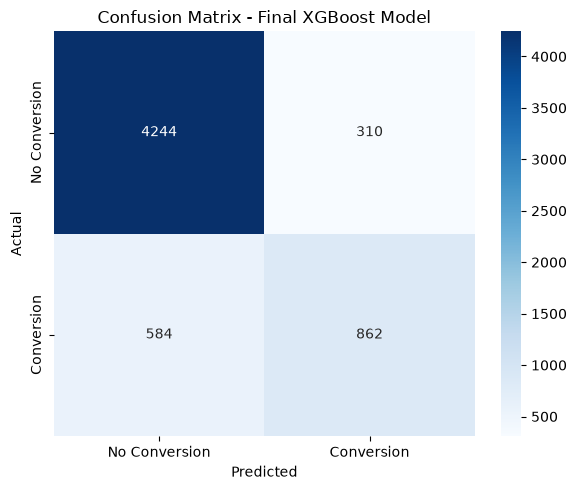

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Conversion", "Conversion"],
    yticklabels=["No Conversion", "Conversion"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final XGBoost Model")
plt.tight_layout()
plt.show()

### 10.3 ROC Curve

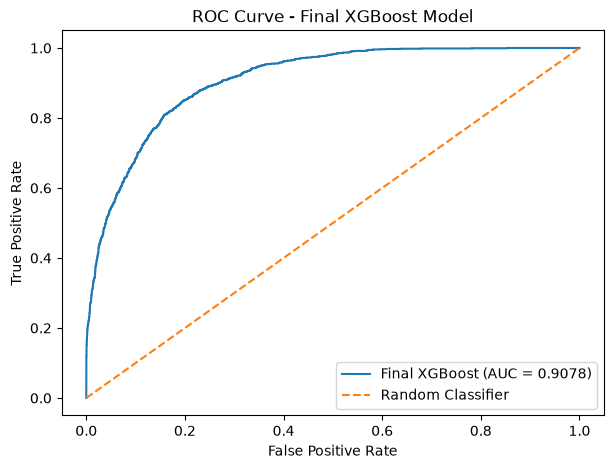

In [104]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
auc_score = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Final XGBoost (AUC = {auc_score:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final XGBoost Model")
plt.legend()
plt.show()

### 10.4 Precision-Recall Curve

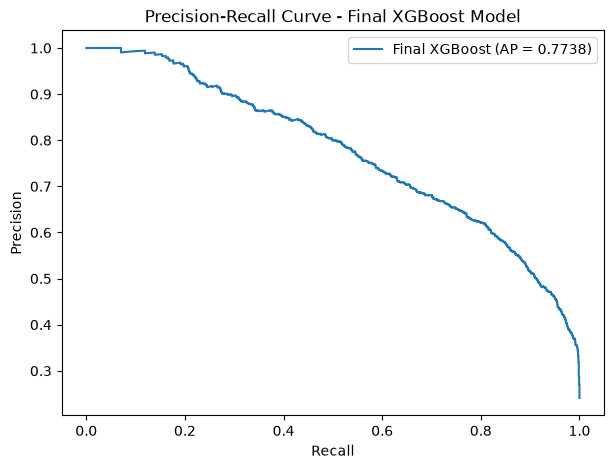

In [107]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_test_proba
)

ap_score = average_precision_score(y_test, y_test_proba)

plt.figure(figsize=(7, 5))

plt.plot(
    recall,
    precision,
    label=f"Final XGBoost (AP = {ap_score:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final XGBoost Model")
plt.legend()
plt.show()

### 10.5 Classification Report

In [108]:
from sklearn.metrics import classification_report

print("Classification Report - Final XGBoost Model")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["No Conversion", "Conversion"]
    )
)

Classification Report - Final XGBoost Model
               precision    recall  f1-score   support

No Conversion       0.88      0.93      0.90      4554
   Conversion       0.74      0.60      0.66      1446

     accuracy                           0.85      6000
    macro avg       0.81      0.76      0.78      6000
 weighted avg       0.84      0.85      0.85      6000



## Final Model Evaluation Summary

- The final **XGBoost** model achieved a test accuracy of **85.22%**.
- It achieved a conversion **precision of 74%**, meaning that 74% of the users predicted as converters were actually converters.
- It achieved a conversion **recall of 60%**, meaning that the model correctly identified around 60% of the actual conversion cases.
- It achieved a conversion **F1-score of 66%**, providing a balance between precision and recall.
- The **ROC-AUC of 0.9072** indicates strong ability to distinguish between conversion and non-conversion cases.
- Overall, the model provides a good balance of **accuracy, precision, recall, F1-score and ROC-AUC**, making it suitable for identifying users with higher conversion potential.

## 11. Feature Importance Analysis

- XGBoost feature importance is used to identify the features that contribute most to the predictions of the final model.
- The features are ranked based on their importance scores generated by the **selected-feature XGBoost model**.
- The **top 15 features** are visualized to understand the most influential factors associated with advertisement conversion.
- This analysis helps interpret the model and identify the important factors that influence conversion predictions.

In [110]:
feature_importance = pd.DataFrame({
    "Feature": x_train_selected.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,previous_conversion_rate,0.148287
12,campaign_type_Conversion,0.106817
2,previous_ad_clicks,0.083103
1,engagement_score,0.078747
10,campaign_type_Awareness,0.070340
13,campaign_type_Retargeting,0.048448
19,user_segment_New User,0.043900
18,user_segment_Loyal Customer,0.041948
14,ad_position_Bottom,0.040532
11,campaign_type_Consideration,0.038952


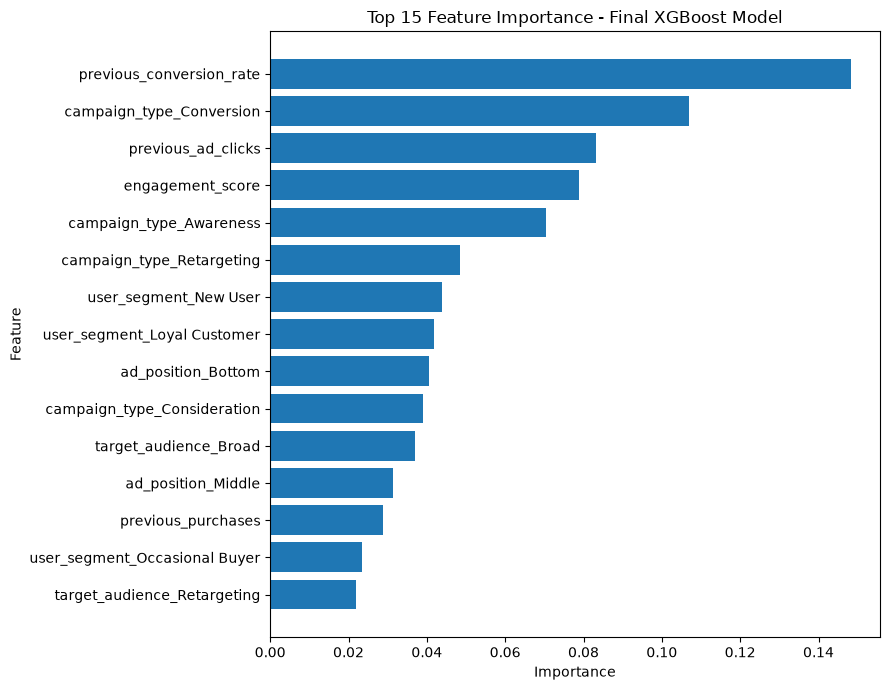

In [111]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance - Final XGBoost Model")
plt.tight_layout()
plt.show()


## 12. Business Decision Support

- The final **XGBoost model** generates a conversion probability for each advertisement interaction.
- These conversion probabilities can help advertisers identify **high-potential and low-potential users or advertisement opportunities**.
- Businesses can use the predictions to **prioritize advertising efforts and improve campaign decisions**.
- Conversion probabilities can be grouped into different **potential categories** to make the model output easier to understand and use for business decision-making.

### 12.1 Conversion Probability

In [112]:
prediction_results = pd.DataFrame({
    "Actual Conversion": y_test.values,
    "Predicted Conversion": y_test_pred,
    "Conversion Probability": y_test_proba
})

prediction_results.head(10)

,Actual Conversion,Predicted Conversion,Conversion Probability
0,0,0,0.031060
1,1,1,0.639264
2,1,1,0.626298
3,0,0,0.077937
4,0,0,0.033413
5,0,0,0.003681
6,0,0,0.031608
7,0,0,0.012766
8,0,0,0.352728
9,0,0,0.001070


### 12.2 Conversion Potential Categories

In [113]:
prediction_results["Conversion Category"] = pd.cut(
    prediction_results["Conversion Probability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low Potential", "Medium Potential", "High Potential"],
    include_lowest=True
)

prediction_results.head(10)

,Actual Conversion,Predicted Conversion,Conversion Probability,Conversion Category
0,0,0,0.031060,Low Potential
1,1,1,0.639264,High Potential
2,1,1,0.626298,High Potential
3,0,0,0.077937,Low Potential
4,0,0,0.033413,Low Potential
5,0,0,0.003681,Low Potential
6,0,0,0.031608,Low Potential
7,0,0,0.012766,Low Potential
8,0,0,0.352728,Medium Potential
9,0,0,0.001070,Low Potential


### 12.3 Business Interpretation

- The model assigns each advertisement interaction a **conversion probability**.
- **Low-potential** interactions can be reviewed for **campaign optimization**.
- **Medium-potential** interactions can be considered for **further analysis or testing**.
- **High-potential** interactions can be prioritized for **advertising attention and targeted campaigns**.

# 13. Conclusion

- A machine learning-based classification system was developed to predict whether a sponsored advertisement interaction will result in a purchase.
- The final **XGBoost model** achieved a test accuracy of **85.22%**, conversion precision of **74%**, conversion recall of **60%**, and conversion F1-score of **66%**.
- The model achieved a **ROC-AUC of 0.9072**, indicating strong ability to distinguish between conversion and non-conversion cases.
- The model generates **conversion probabilities** that can help businesses identify high-, medium-, and low-potential advertising opportunities.
- These insights can support **campaign optimization, prioritization of higher-conversion opportunities, and more informed advertising decisions**.